In [127]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler



In [2]:
data=pd.read_csv("bank_additional_full.csv")
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,True
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,False
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,False
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,True


In [3]:
data = data.replace('unknown', np.nan)

In [4]:
data.isnull().sum()

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp_var_rate         0
cons_price_idx       0
cons_conf_idx        0
euribor3m            0
nr_employed          0
y                    0
dtype: int64

In [5]:
data = data.dropna()
data.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64

In [6]:
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,True
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,False
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,False
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,True


In [7]:
data.duplicated().sum()


10

In [8]:
data=data.drop_duplicates()

In [9]:
data.duplicated().sum()


0

In [10]:

# get unique values for each column in the data set
unique_values_per_column = {}
for column in data.columns:
    unique_values_per_column[column] = data[column].unique()

unique_values_per_column


{'age': array([56, 37, 40, 59, 24, 25, 29, 57, 35, 50, 30, 55, 41, 54, 34, 52, 32,
        38, 45, 39, 60, 53, 51, 48, 44, 31, 49, 33, 42, 36, 43, 46, 28, 58,
        27, 47, 26, 22, 23, 20, 21, 18, 70, 61, 66, 76, 67, 73, 88, 95, 19,
        68, 75, 63, 62, 65, 72, 64, 71, 69, 78, 85, 80, 79, 77, 83, 81, 74,
        82, 17, 87, 91, 94, 86, 84, 89], dtype=int64),
 'job': array(['housemaid', 'services', 'admin.', 'technician', 'blue-collar',
        'unemployed', 'retired', 'entrepreneur', 'management', 'student',
        'self-employed'], dtype=object),
 'marital': array(['married', 'single', 'divorced'], dtype=object),
 'education': array(['basic.4y', 'high.school', 'basic.6y', 'professional.course',
        'basic.9y', 'university.degree', 'illiterate'], dtype=object),
 'default': array(['no', 'yes'], dtype=object),
 'housing': array(['no', 'yes'], dtype=object),
 'loan': array(['no', 'yes'], dtype=object),
 'contact': array(['telephone', 'cellular'], dtype=object),
 'month': array([

In [11]:
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,True
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,False
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,False
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,True


In [12]:
# Encode the columns and create a new columns
label_encoder = LabelEncoder()

data['job'] = label_encoder.fit_transform(data['job'])
data['marital'] = label_encoder.fit_transform(data['marital'])
data['education'] = label_encoder.fit_transform(data['education'])
data['default'] = label_encoder.fit_transform(data['default'])
data['housing'] = label_encoder.fit_transform(data['housing'])
data['loan'] = label_encoder.fit_transform(data['loan'])
data['contact'] = label_encoder.fit_transform(data['contact'])
data['poutcome'] = label_encoder.fit_transform(data['poutcome'])
data['y'] = label_encoder.fit_transform(data['y'])


print(data)

       age  job  marital  education  default  housing  loan  contact month  \
0       56    3        1          0        0        0     0        1   may   
2       37    7        1          3        0        1     0        1   may   
3       40    0        1          1        0        0     0        1   may   
4       56    7        1          3        0        0     1        1   may   
6       59    0        1          5        0        0     0        1   may   
...    ...  ...      ...        ...      ...      ...   ...      ...   ...   
41183   73    5        1          5        0        1     0        0   nov   
41184   46    1        1          5        0        0     0        0   nov   
41185   56    5        1          6        0        1     0        0   nov   
41186   44    9        1          5        0        0     0        0   nov   
41187   74    5        1          5        0        1     0        0   nov   

      day_of_week  ...  campaign  pdays  previous  poutcome  em

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4104\2185673610.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['job'] = label_encoder.fit_transform(data['job'])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4104\2185673610.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['marital'] = label_encoder.fit_transform(data['marital'])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4104\2185673610.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

In [13]:
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,3,1,0,0,0,0,1,may,mon,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,may,mon,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,may,mon,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,may,mon,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
6,59,0,1,5,0,0,0,1,may,mon,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,5,1,5,0,1,0,0,nov,fri,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,1,1,5,0,0,0,0,nov,fri,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,5,1,6,0,1,0,0,nov,fri,...,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,9,1,5,0,0,0,0,nov,fri,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1


In [14]:
# Encode the month and create a new month

month_name_to_number = {
    'mar': 3,
    'apr': 4,
    'may': 5,
    'jun': 6,
    'jul': 7,
    'aug': 8,
    'sep': 9,
    'oct': 10,
    'nov': 11,
    'dec': 12
}

data['month'] = data['month'].map(month_name_to_number)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4104\1748437097.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['month'] = data['month'].map(month_name_to_number)


In [15]:
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,3,1,0,0,0,0,1,5,mon,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,5,mon,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,5,mon,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,5,mon,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
6,59,0,1,5,0,0,0,1,5,mon,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,5,1,5,0,1,0,0,11,fri,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,1,1,5,0,0,0,0,11,fri,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,5,1,6,0,1,0,0,11,fri,...,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,9,1,5,0,0,0,0,11,fri,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1


In [16]:
# Encode the day_of_week and create a new day_of_week

day_of_week_to_number = {
    'mon': 1,
    'tue': 2,
    'wed': 3,
    'thu': 4,
    'fri': 5
}
data['day_of_week'] = data['day_of_week'].map(day_of_week_to_number)

data

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4104\1945478814.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['day_of_week'] = data['day_of_week'].map(day_of_week_to_number)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,3,1,0,0,0,0,1,5,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,5,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,5,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,5,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
6,59,0,1,5,0,0,0,1,5,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,5,1,5,0,1,0,0,11,5,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,1,1,5,0,0,0,0,11,5,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,5,1,6,0,1,0,0,11,5,...,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,9,1,5,0,0,0,0,11,5,...,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6,1


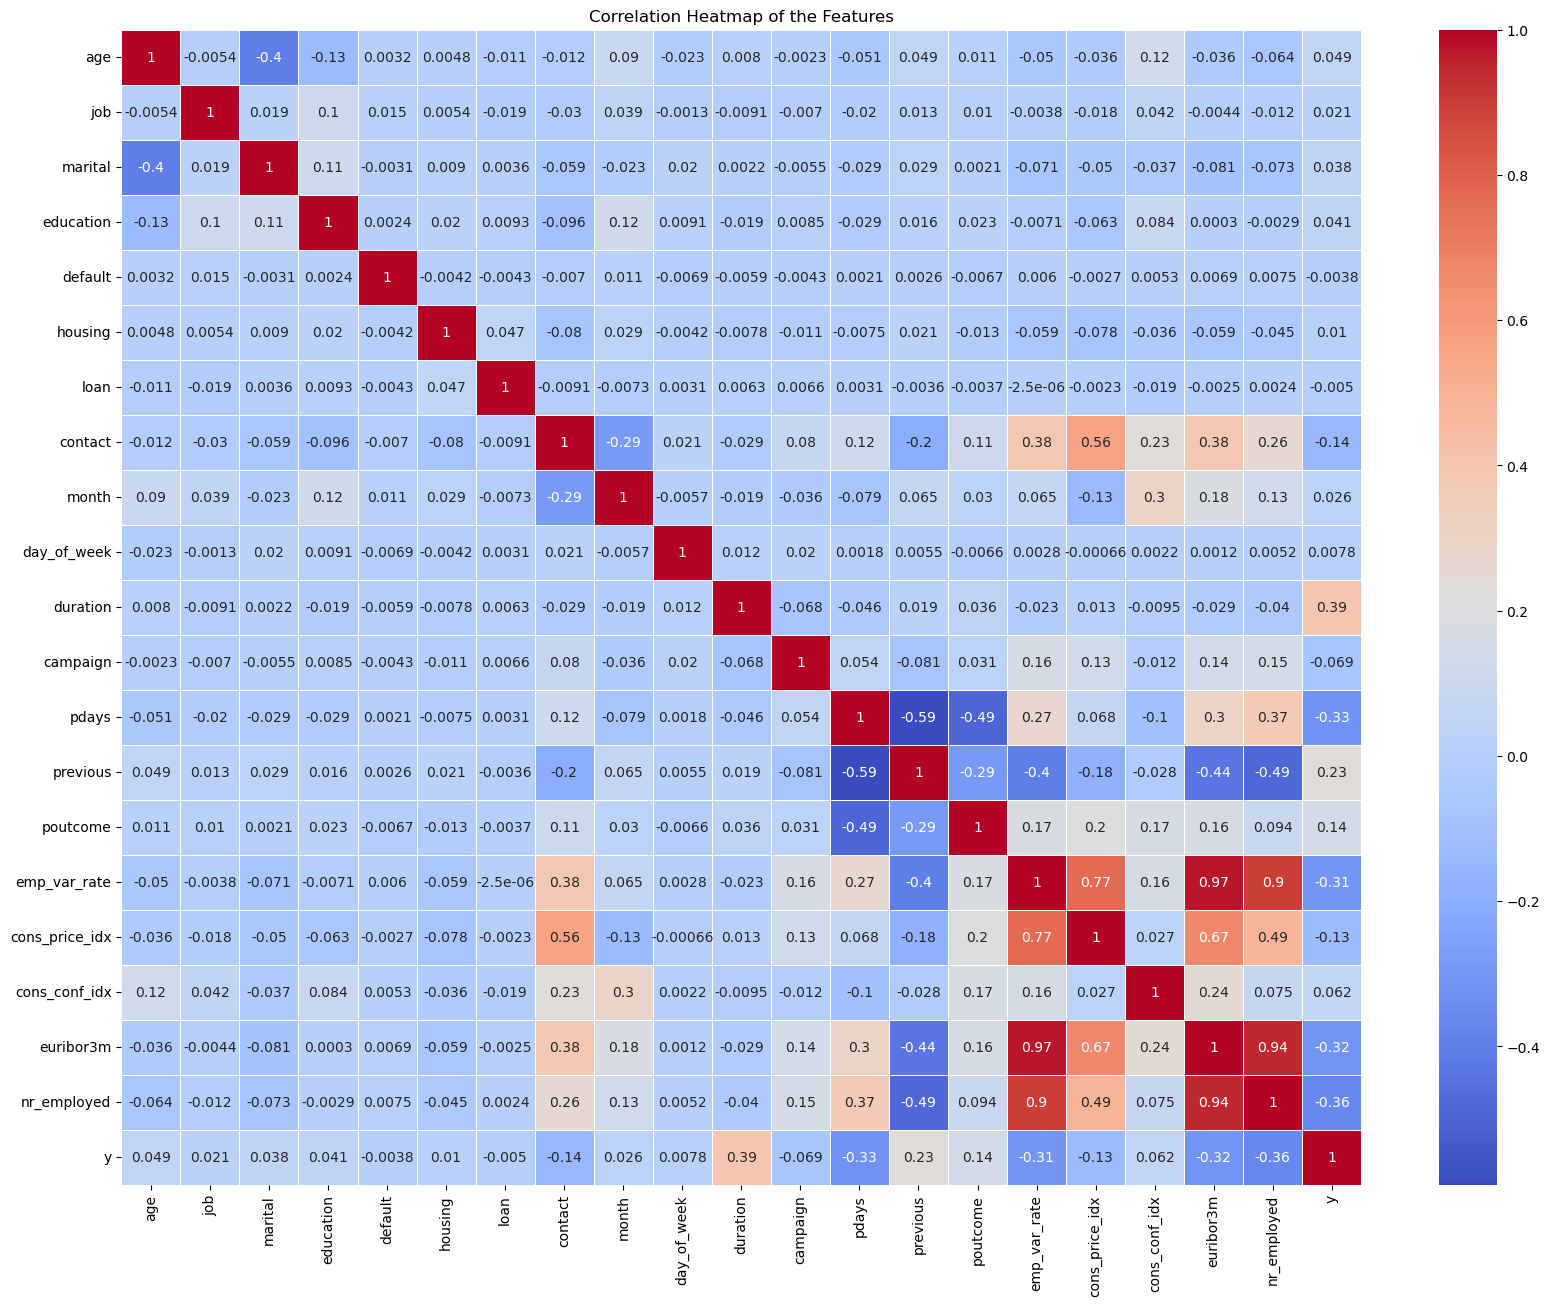

In [17]:
correlation_matrix = data.corr()
# Create a heatmap of correlations
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of the Features')
plt.show()

# cluster

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of

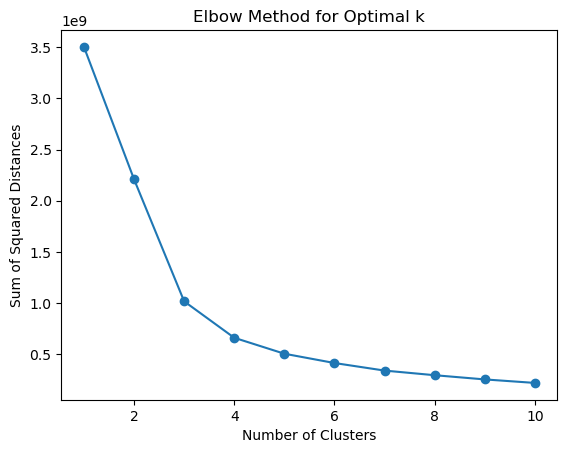

In [18]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = data.drop('y', axis=1)
# Use the Elbow Method to find the optimal number of clusters
dec = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    dec.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.plot(range(1, 11), dec, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method for Optimal k')
plt.show()


In [19]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [20]:
## Splitting the dataset to x and y
x_data = data.drop('y', axis=1)
y_data = data['y']

# learning curve

In [21]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(0.1, 1.0, 5)):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")
    plt.legend(loc="best")
    return plt

# models before outlier detection Algorthims

In [22]:
#Split the dataset

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3,random_state=42)

# DecisionTree

In [23]:
DecisionTree = DecisionTreeClassifier(min_samples_leaf=100,random_state=42)

DecisionTree.fit(x_train, y_train)

DecisionTreeClassifier(min_samples_leaf=100, random_state=42)

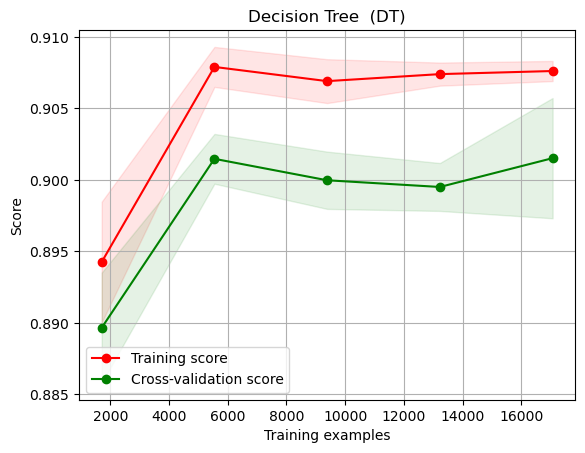

In [24]:
plot_learning_curve(DecisionTree, "Decision Tree  (DT)", x_train, y_train, cv=5)
plt.show()

In [25]:
y_pred = DecisionTree.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9017935258092739


# RandomForest

In [26]:
RandomForest = RandomForestClassifier(min_samples_leaf=100, random_state=42)

RandomForest.fit(x_train, y_train)

RandomForestClassifier(min_samples_leaf=100, random_state=42)

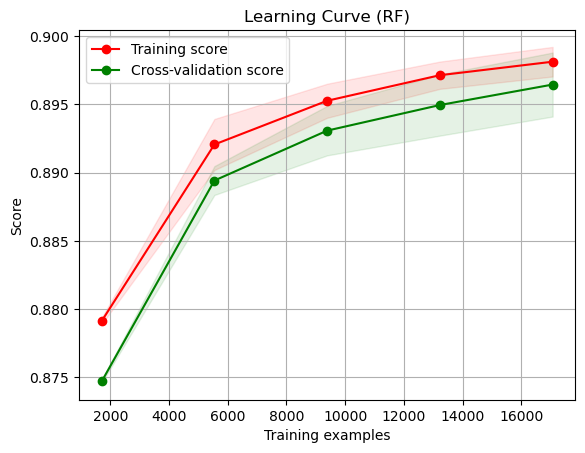

In [27]:
plot_learning_curve(RandomForest, "Learning Curve (RF)", x_train, y_train, cv=5)
plt.show()

In [28]:
y_pred = RandomForest.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8973097112860893


#  Support Vector Machine (SVM)

In [29]:
SVC = SVC(random_state = 42)
SVC.fit(x_train, y_train)

SVC(random_state=42)

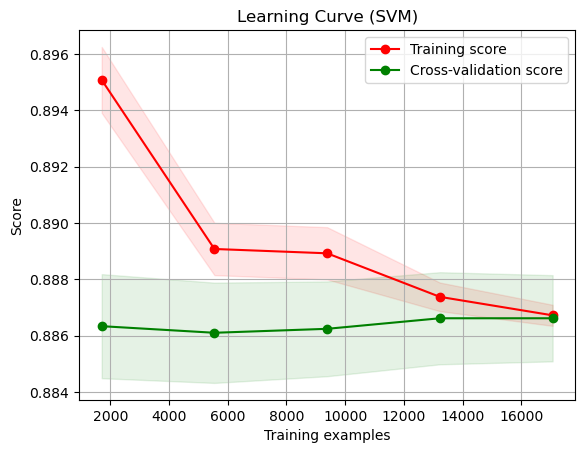

In [30]:
plot_learning_curve(SVC, "Learning Curve (SVM)", x_train, y_train, cv=5)
plt.show()

In [31]:
y_pred = SVC.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8835301837270341


# outliers

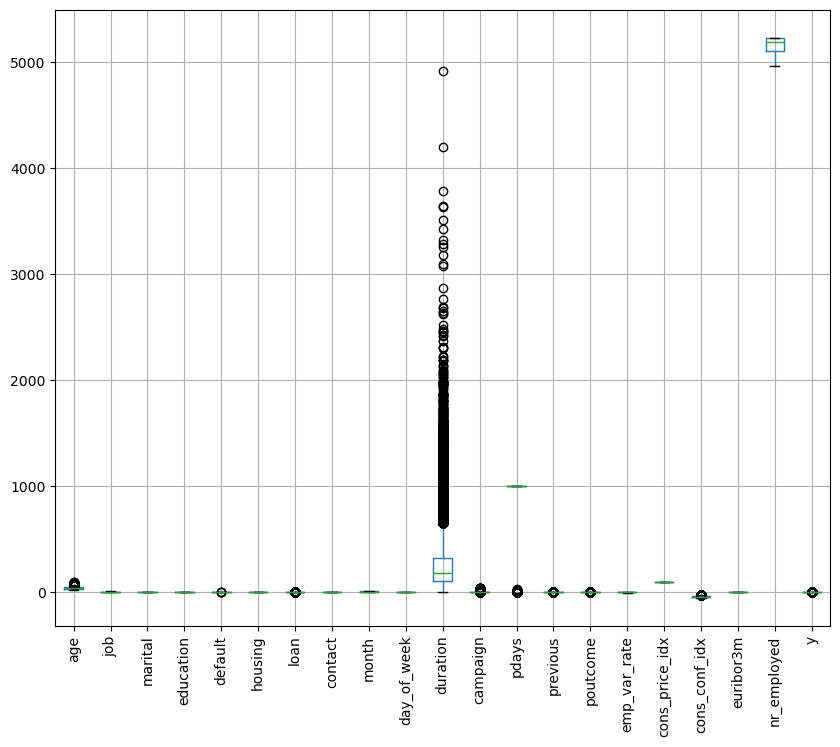

In [32]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'data'
boxplot = data.boxplot(figsize=(10, 8), rot=90)  # Set rot=90 to rotate the labels 90 degrees
plt.show()


In [33]:
#Define the outlier
outlierDetector1 =  EllipticEnvelope(contamination=0.2)
result=outlierDetector1.fit_predict(x_data)

In [34]:
Outliers=x_data[result==-1]
print("Number of detected outliers is " +str(len(Outliers)))

Number of detected outliers is 6096


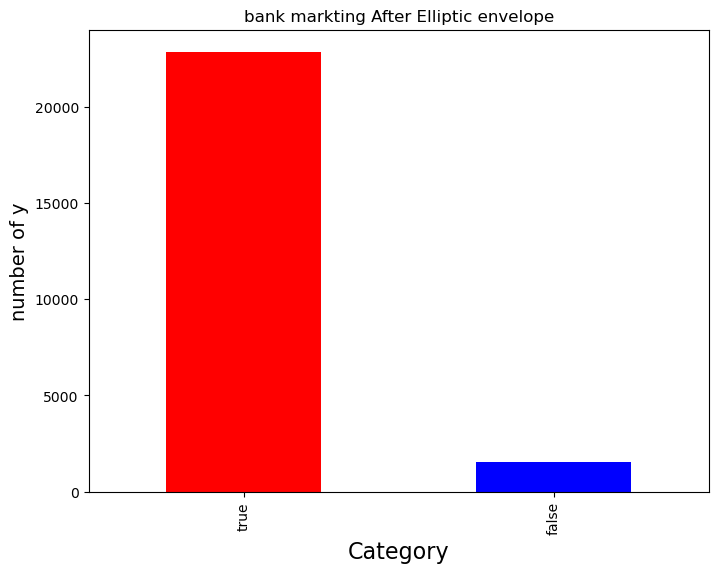

In [35]:
ax=y_data[result!=-1].value_counts().plot(kind='bar',color=['red','blue'],
                                          title='bank markting After Elliptic envelope',figsize=(8, 6))

plt.xticks(range(2),['true','false'])
ax.set_xlabel("Category",fontsize=16)
ax.set_ylabel("number of y",fontsize=14)
plt.show()

In [36]:
from sklearn.neighbors import LocalOutlierFactor
#Define the outlier
outlierDetector2 =  LocalOutlierFactor(n_neighbors=20)
result2=outlierDetector2.fit_predict(x_data)

In [37]:
Outliers=x_data[result2==-1]
print("Number of detected outliers is " +str(len(Outliers)))

Number of detected outliers is 253


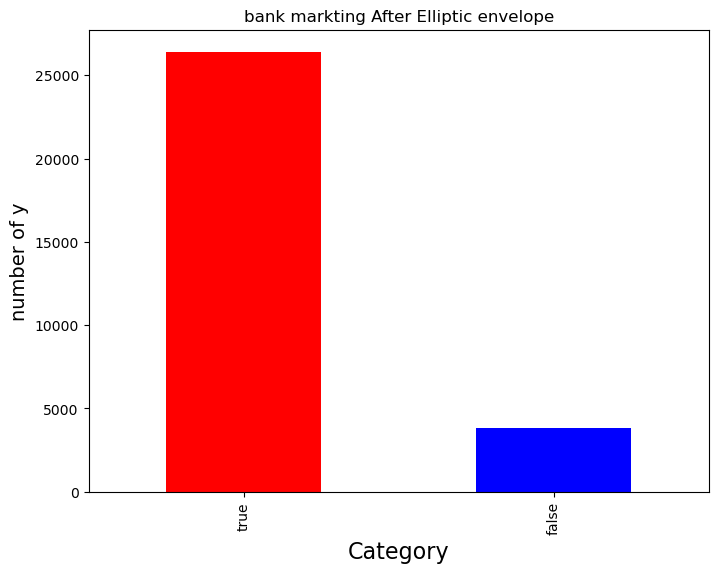

In [38]:
ax=y_data[result2!=-1].value_counts().plot(kind='bar',color=['red','blue'],
                                          title='bank markting After Elliptic envelope',figsize=(8, 6))

plt.xticks(range(2),['true','false'])
ax.set_xlabel("Category",fontsize=16)
ax.set_ylabel("number of y",fontsize=14)
plt.show()

In [39]:
#Define the outlier
outlierDetector =  IsolationForest(n_estimators=100,random_state = 42)
result3=outlierDetector.fit_predict(x_data)

In [40]:
Outliers=x_data[result3==-1]
print("Number of detected outliers is " +str(len(Outliers)))

Number of detected outliers is 8799


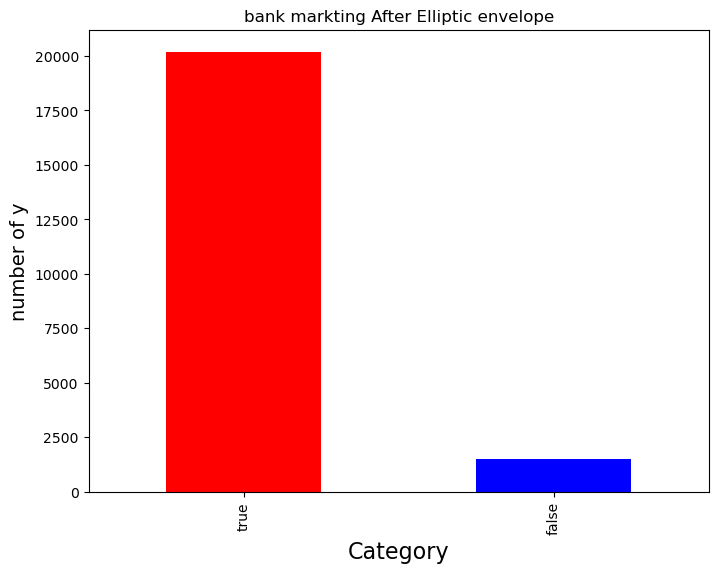

In [41]:
ax=y_data[result3!=-1].value_counts().plot(kind='bar',color=['red','blue'],
                                          title='bank markting After Elliptic envelope',figsize=(8, 6))

plt.xticks(range(2),['true','false'])
ax.set_xlabel("Category",fontsize=16)
ax.set_ylabel("number of y",fontsize=14)
plt.show()

# models after outlier detection Algorthims

In [42]:
newX=x_data[result2!=-1]
newY=y_data[result2!=-1]
x_train, x_test, y_train, y_test = train_test_split(newX, newY, test_size=0.3,random_state=42)


# DecisionTree

In [43]:
DecisionTree = DecisionTreeClassifier(min_samples_leaf=100,random_state=42)

DecisionTree.fit(x_train, y_train)

DecisionTreeClassifier(min_samples_leaf=100, random_state=42)

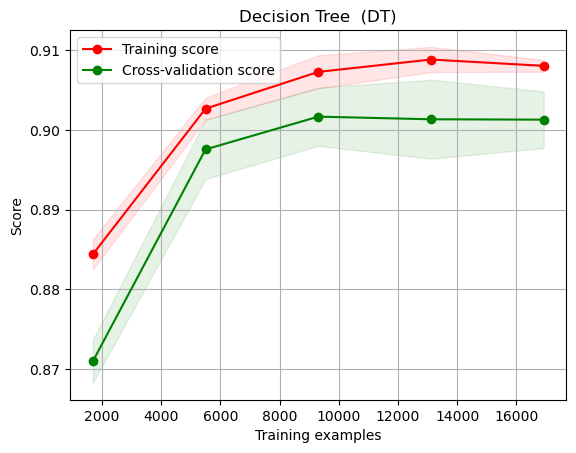

In [44]:
plot_learning_curve(DecisionTree, "Decision Tree  (DT)", x_train, y_train, cv=5)
plt.show()

In [45]:
y_pred = DecisionTree.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9069254521393912


# RandomForest

In [46]:
RandomForest = RandomForestClassifier(min_samples_leaf=100, random_state=42)

RandomForest.fit(x_train, y_train)

RandomForestClassifier(min_samples_leaf=100, random_state=42)

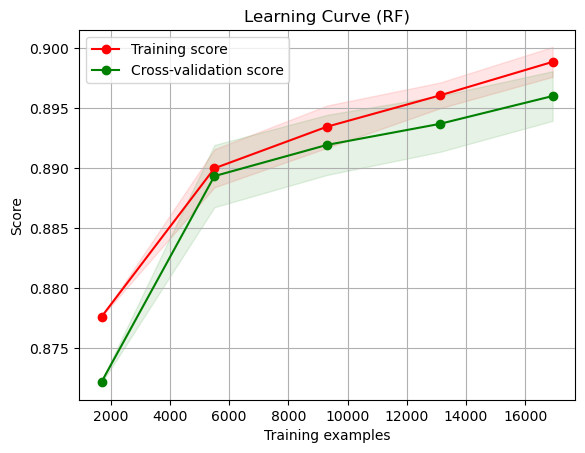

In [47]:
plot_learning_curve(RandomForest, "Learning Curve (RF)", x_train, y_train, cv=5)
plt.show()

In [48]:
y_pred = RandomForest.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8974415527128363


# Support Vector Machine (SVM)

In [51]:
from sklearn.svm import SVC
SVC=SVC(random_state = 42)
SVC.fit(x_train, y_train)



SVC(random_state=42)

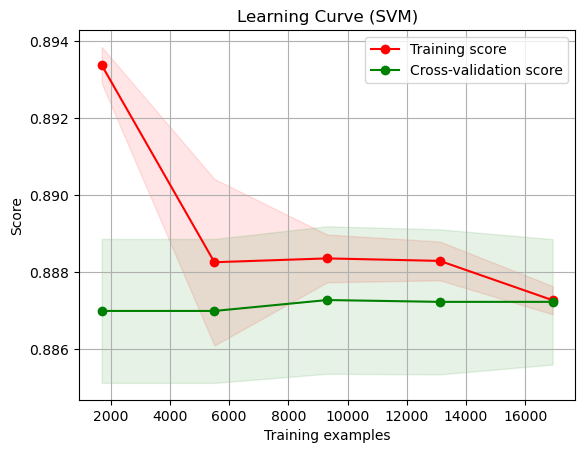

In [52]:
plot_learning_curve(SVC, "Learning Curve (SVM)", x_train, y_train, cv=5)
plt.show()

In [53]:
y_pred = SVC.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8887295985884429


# over sampling


In [70]:
oversample = SMOTE(random_state=42)
overX,overY=oversample.fit_resample(x_data, y_data)

In [72]:
pd.DataFrame(overY,columns=['y'])['y'].value_counts()

y
0    26620
1    26620
Name: count, dtype: int64

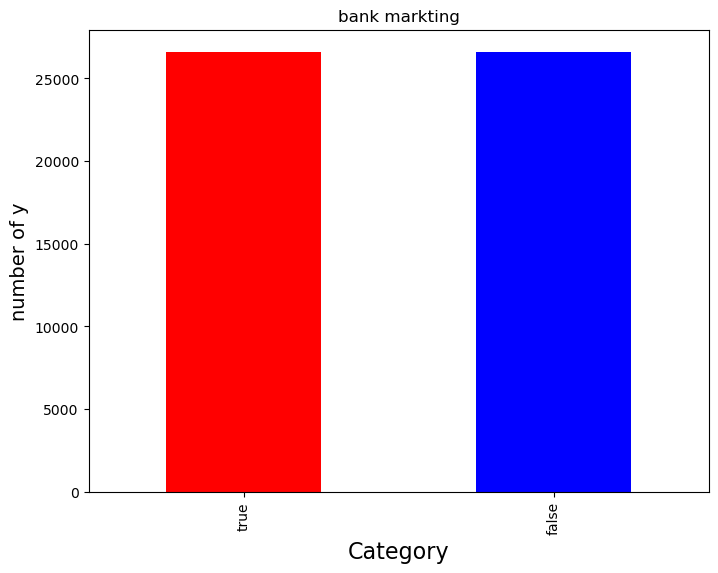

In [73]:

ax=pd.DataFrame(overY,columns=['y'])['y'].value_counts().plot(kind='bar',color=['red','blue'],
                                          title='bank markting',figsize=(8, 6))

plt.xticks(range(2),['true','false'])
ax.set_xlabel("Category",fontsize=16)
ax.set_ylabel("number of y",fontsize=14)
plt.show()

# models after over sampling

In [78]:
scaler = StandardScaler()
x_train, x_test, y_train, y_test = train_test_split(overX, overY, test_size=0.3,random_state=42)
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

# DecisionTree

In [79]:
DecisionTree = DecisionTreeClassifier(min_samples_leaf=100,random_state=42)

DecisionTree.fit(x_train, y_train)

DecisionTreeClassifier(min_samples_leaf=100, random_state=42)

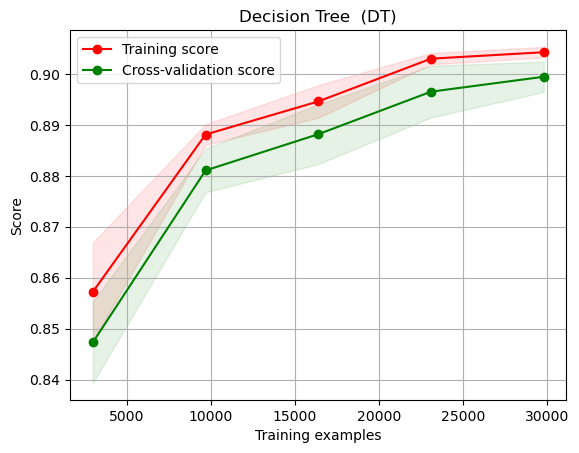

In [80]:
plot_learning_curve(DecisionTree, "Decision Tree  (DT)", x_train, y_train, cv=5)
plt.show()

In [81]:
y_pred = DecisionTree.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8555597295266717


# RandomForest

In [82]:
RandomForest = RandomForestClassifier(min_samples_leaf=100, random_state=42)

RandomForest.fit(x_train, y_train)

RandomForestClassifier(min_samples_leaf=100, random_state=42)

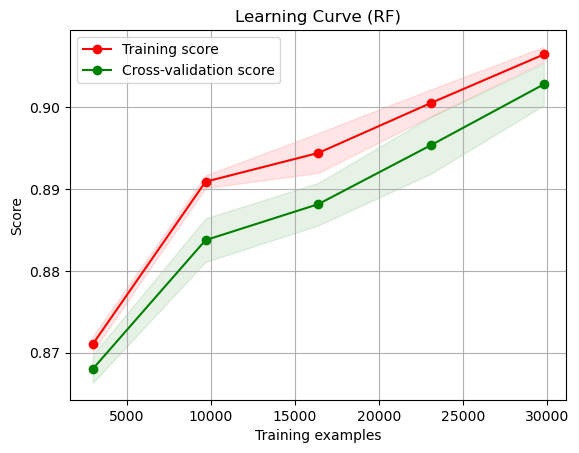

In [83]:
plot_learning_curve(RandomForest, "Learning Curve (RF)", x_train, y_train, cv=5)
plt.show()

In [84]:
y_pred = RandomForest.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8566240921612822


# Support Vector Machine (SVM)

In [85]:
from sklearn.svm import SVC
SVC=SVC(random_state = 42)
SVC.fit(x_train, y_train)



SVC(random_state=42)

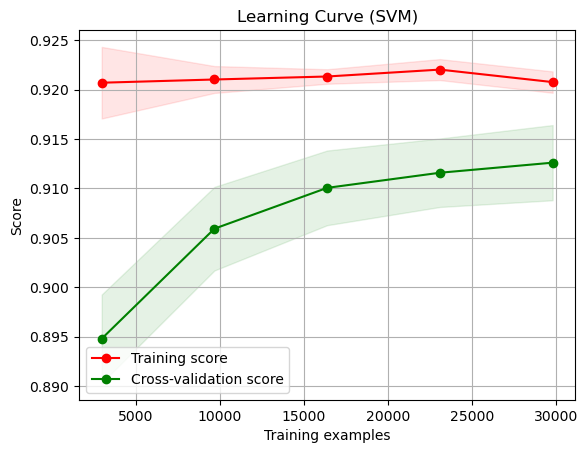

In [86]:
plot_learning_curve(SVC, "Learning Curve (SVM)", x_train, y_train, cv=5)
plt.show()

In [87]:
y_pred = SVC.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.913786626596544


# under sampling

In [94]:
from imblearn.under_sampling import RandomUnderSampler

undersample = RandomUnderSampler(random_state=42)
underX, underY = undersample.fit_resample(x_data, y_data)


In [95]:
pd.DataFrame(underY,columns=['y'])['y'].value_counts()

y
0    3858
1    3858
Name: count, dtype: int64

# models after under sampling

In [106]:
scaler = StandardScaler()
x_train, x_test, y_train, y_test = train_test_split(underX, underY, test_size=0.3,random_state=42)
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

# DecisionTree

In [116]:
DecisionTree = DecisionTreeClassifier(min_samples_leaf=80,random_state=42)

DecisionTree.fit(x_train, y_train)

DecisionTreeClassifier(min_samples_leaf=80, random_state=42)

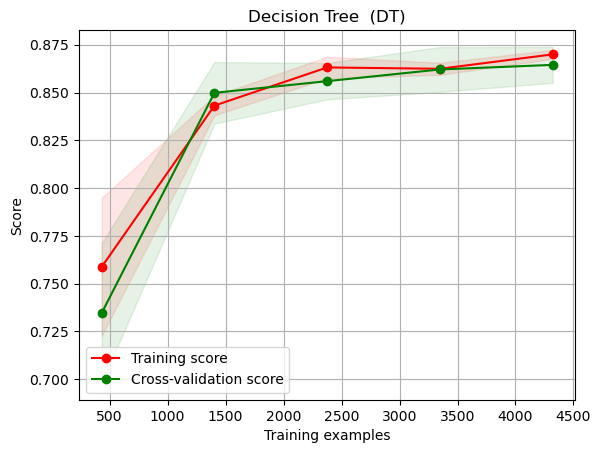

In [117]:
plot_learning_curve(DecisionTree, "Decision Tree  (DT)", x_train, y_train, cv=5)
plt.show()

In [118]:
y_pred = DecisionTree.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8609071274298056


# RandomForest

In [119]:
RandomForest = RandomForestClassifier(min_samples_leaf=80, random_state=42)

RandomForest.fit(x_train, y_train)

RandomForestClassifier(min_samples_leaf=80, random_state=42)

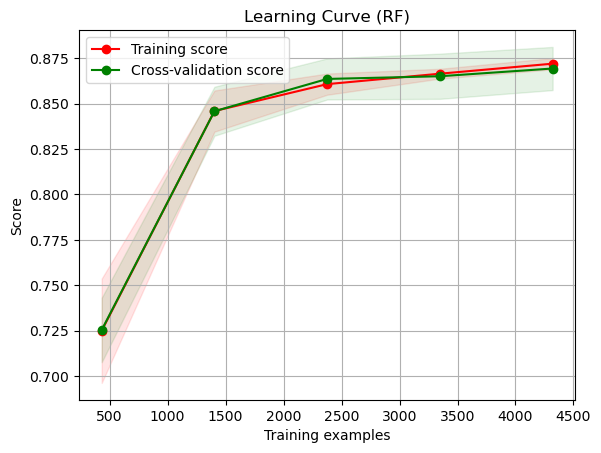

In [120]:
plot_learning_curve(RandomForest, "Learning Curve (RF)", x_train, y_train, cv=5)
plt.show()

In [121]:
y_pred = RandomForest.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8578833693304536


# Support Vector Machine (SVM)

In [113]:
from sklearn.svm import SVC
SVC=SVC(random_state = 42)
SVC.fit(x_train, y_train)



SVC(random_state=42)

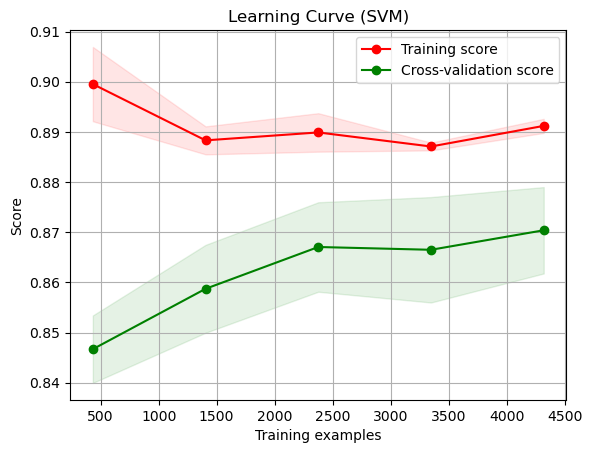

In [114]:
plot_learning_curve(SVC, "Learning Curve (SVM)", x_train, y_train, cv=5)
plt.show()

In [115]:
y_pred = SVC.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8583153347732182
